<a href="https://colab.research.google.com/github/arshpreetw11/Churn-predictor/blob/main/proj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [40]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [41]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
#total charges (object)-->numeric
#tenure->labels
#dependency->0,1   make avg monthly charges = monthly charge/tenure+1

In [44]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [45]:
from sklearn.model_selection import train_test_split

In [46]:
X=df.drop(columns=['customerID','Churn'])
y=(df['Churn'].map({"Yes":1,"No":0}).astype('int64'))

In [109]:
X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y)

In [110]:
from sklearn.base import BaseEstimator,TransformerMixin

In [111]:
class FeatureEngineer(BaseEstimator,TransformerMixin):
  def __init__(self):
    pass
  def fit(self,X,y=None):
    return self
  def transform(self,X):
    X=X.copy()
    X['TotalCharges']=pd.to_numeric(X['TotalCharges'],errors="coerce")
    Bins=[0,12,24,36,48,60,72]
    labels=[0,1,2,3,4,5]
    X['TenureGroup']=pd.cut(X['tenure'],bins=Bins,labels=labels,include_lowest=True).astype('int64')
    X['Average_Monthly_Charges']=X['TotalCharges']/(X['tenure']+1)
    binary_cols = [
            "Partner",
            "Dependents",
            "PhoneService",
            "PaperlessBilling",
            "MultipleLines",
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport",
            "StreamingTV",
            "StreamingMovies"
        ]
    for col in binary_cols:
      X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
    X['SeniorCitizen']=X['SeniorCitizen'].astype('int64')
    servicecols=['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup'
    ,'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    X['TotalServices']=X[servicecols].sum(axis=1)
    return X



In [85]:
fe=FeatureEngineer()
X_train_tnf=fe.fit_transform(X_train)
X_test_tnf=fe.transform(X_test)

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

In [86]:
X_train_tnf

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TenureGroup,Average_Monthly_Charges,TotalServices
5941,Female,0,0,0,36,0,0,DSL,0,1,...,0,0,Month-to-month,1,Bank transfer (automatic),34.85,1267.20,2,34.248649,2
1613,Male,0,0,0,34,1,0,No,0,0,...,0,0,Month-to-month,0,Mailed check,19.70,675.60,2,19.302857,1
1449,Female,1,0,0,6,1,0,No,0,0,...,0,0,Month-to-month,0,Bank transfer (automatic),19.50,106.80,0,15.257143,1
775,Female,0,1,0,72,1,1,Fiber optic,1,1,...,1,1,Two year,1,Credit card (automatic),110.65,8065.65,5,110.488356,7
4930,Female,0,0,0,1,1,0,DSL,0,0,...,0,0,Month-to-month,1,Credit card (automatic),44.55,44.55,0,22.275000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,Female,0,0,0,2,1,0,No,0,0,...,0,0,Month-to-month,1,Mailed check,20.45,42.45,0,14.150000,1
6774,Female,0,0,0,1,1,0,No,0,0,...,0,0,Month-to-month,0,Mailed check,19.65,19.65,0,9.825000,1
210,Male,0,0,0,2,1,0,DSL,0,0,...,0,0,Month-to-month,1,Credit card (automatic),46.00,84.50,0,28.166667,1
1328,Female,0,1,0,23,1,0,DSL,0,0,...,0,0,Month-to-month,0,Electronic check,54.25,1221.55,1,50.897917,3


<Axes: xlabel='MonthlyCharges', ylabel='Density'>

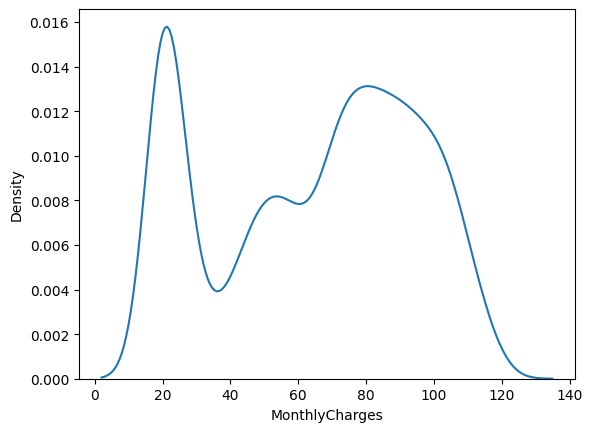

In [87]:
import seaborn as sns
sns.kdeplot(X_train_tnf['MonthlyCharges'])

<Axes: xlabel='TotalCharges', ylabel='Density'>

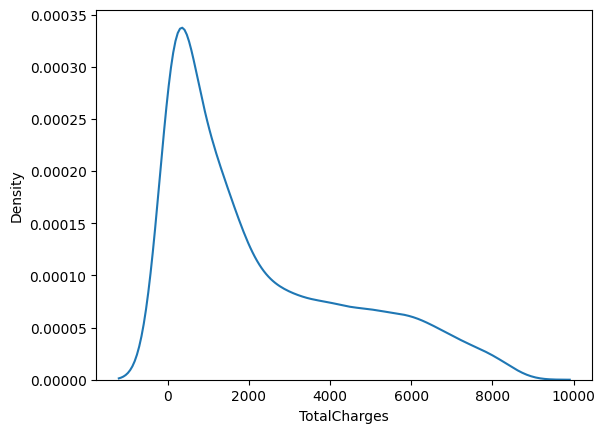

In [88]:
sns.kdeplot(X_train_tnf['TotalCharges'])

<Axes: xlabel='Average_Monthly_Charges', ylabel='Density'>

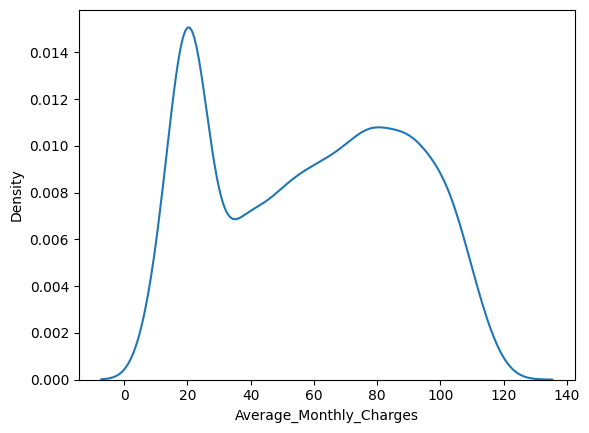

In [89]:
sns.kdeplot(X_train_tnf['Average_Monthly_Charges'])

In [90]:
skewnesss_standardscale=['TotalCharges']
standardscale=['TenureGroup','TotalServices','Average_Monthly_Charges','MonthlyCharges','tenure']
one_hot_encode=['gender','InternetService','Contract','PaymentMethod']
sorted_cols=['SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup','StreamingTV',
             'StreamingMovies','PaperlessBilling','DeviceProtection']

In [91]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
import numpy as np
import pandas as pd

class SkewnessWrapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.funcs = {}

    def fit(self, X, y=None):
        self._cols = list(self.cols)
        self.funcs = {}

        for col in self._cols:
            skew_val = X[col].dropna().skew()

            if skew_val > 1.5 and (X[col] >= 0).all():
                ft = FunctionTransformer(np.log1p, validate=False)
            else:
                ft = PowerTransformer(
                    method="yeo-johnson",
                    standardize=False
                )

            ft.fit(X[[col]])
            self.funcs[col] = ft

        return self

    def transform(self, X, y=None):
        X = X.copy()

        for col in self._cols:
            ft = self.funcs[col]
            X[col] = ft.transform(X[[col]]).ravel()

        return X

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [93]:
skewnesss_standard_pipeline=Pipeline([('tnf1',SkewnessWrapper(skewnesss_standardscale)),('tnf2',StandardScaler())])
standardscale_pipeline=Pipeline([('tnf1',StandardScaler())])
one_hot_pipeline=Pipeline([('ohe',OneHotEncoder(handle_unknown="ignore",drop=None,sparse_output=False))])
binary_pipeline=Pipeline([("identity", FunctionTransformer(validate=False))])

In [94]:
from sklearn.compose import ColumnTransformer

In [95]:
clf=ColumnTransformer(transformers=[('skew',skewnesss_standard_pipeline,skewnesss_standardscale),("scaled",standardscale_pipeline,standardscale)
,('onehot',one_hot_pipeline,one_hot_encode),('sorted',binary_pipeline,sorted_cols)],remainder='drop')

In [96]:
X_train_tnf_1=clf.fit_transform(X_train_tnf)
X_test_tnf_1=clf.transform(X_test_tnf)

In [97]:
y_train.value_counts()

,count
Churn,
0,3880
1,1402


In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

In [106]:
!pip install optuna

In [115]:
def objective1(trial):
  n_estimators=trial.suggest_int("n_estimators",100,200)
  max_depth=trial.suggest_int("max_depth",3,11)
  min_samples_leaf=trial.suggest_int("min_samples_leaf",1,10)
  min_samples_split=trial.suggest_int("min_samples_split",4,10)
  bootstrap=trial.suggest_categorical("bootstrap",[True,False])
  max_samples=(trial.suggest_float("max_samples",.4,.9)
  if bootstrap else None)

  max_features=trial.suggest_categorical("max_features",['sqrt','log2',.5])
  criterion=trial.suggest_categorical("criterion",['gini','entropy'])

  model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        max_samples=max_samples,
        criterion=criterion,
        random_state=42,
        n_jobs=-1,class_weight="balanced"
    )
  pipeline=Pipeline([('feature_engineering',FeatureEngineer()),('preprocess',clf),('model',model)])
  score=cross_val_score(pipeline,X_train,y_train,cv=3,scoring='roc_auc',n_jobs=-1).mean()
  return score

In [116]:
import optuna
study=optuna.create_study(direction='maximize')
study.optimize(objective1,n_trials=35)

[I 2025-12-16 10:13:57,754] A new study created in memory with name: no-name-24663734-99e6-46f7-824d-af4ebf5cd9c2
[I 2025-12-16 10:14:03,591] Trial 0 finished with value: 0.8432023531032082 and parameters: {'n_estimators': 125, 'max_depth': 4, 'min_samples_leaf': 9, 'min_samples_split': 5, 'bootstrap': False, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.8432023531032082.
[I 2025-12-16 10:14:08,073] Trial 1 finished with value: 0.8410576043951369 and parameters: {'n_estimators': 175, 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 4, 'bootstrap': False, 'max_features': 0.5, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8432023531032082.
[I 2025-12-16 10:14:11,718] Trial 2 finished with value: 0.8362223865587742 and parameters: {'n_estimators': 122, 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 6, 'bootstrap': False, 'max_features': 0.5, 'criterion': 'gini'}. Best is trial 0 with value: 0.8432023531032082.
[I 2025-12-16 1

In [118]:
print("best roc value ",study.best_value)
print("best parameters ",study.best_params)


best roc value  0.8475629887490345
best parameters  {'n_estimators': 169, 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 9, 'bootstrap': True, 'max_samples': 0.8342995947494729, 'max_features': 'sqrt', 'criterion': 'entropy'}


In [119]:
best_params=study.best_params

In [125]:
best_rf = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    bootstrap=best_params["bootstrap"],
    max_samples=best_params["max_samples"] if best_params["bootstrap"] else None,
    criterion=best_params["criterion"],
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
final_rf_pipeline=Pipeline([('feature_engineering',FeatureEngineer()),('preprocess',clf),('model',best_rf)])
final_rf_pipeline.fit(X_train,y_train)

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                ('preprocess',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('tnf1',
                                                                   SkewnessWrapper(cols=['TotalCharges'])),
                                                                  ('tnf2',
                                                                   StandardScaler())]),
                                                  ['TotalCharges']),
                                                 ('scaled',
                                                  Pipeline(steps=[('tnf1',
                                                                   StandardScaler())]),
                                                  ['TenureGroup',
                                                   'TotalServices',
                                                   'Average_Monthly_Charges',
                                                   'MonthlyCharges',...
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling',
                                                   'DeviceProtection'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=7,
                                        max_samples=0.8342995947494729,
                                        min_samples_leaf=4, min_samples_split=9,
                                        n_estimators=169, n_jobs=-1,
                                        random_state=42))])

In [126]:
from sklearn.metrics import roc_auc_score

In [127]:
roc_auc_score(y_test,final_rf_pipeline.predict_proba(X_test)[:,1])

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

np.float64(0.8397727611211687)

In [128]:
accuracy_score(y_test,final_rf_pipeline.predict(X_test))

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

0.750709823963657

In [130]:
from sklearn.metrics import classification_report

In [131]:
print(classification_report(y_test,final_rf_pipeline.predict(X_test)))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1294
           1       0.52      0.78      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.76      1761



/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

In [133]:
def objective2(trial):
  params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),
    }
  model=XGBClassifier(**params,objective='binary:logistic',eval_metric='auc',tree_method='hist',random_state=42,n_jobs=-1)
  pipeline=Pipeline([('feature_engineering',FeatureEngineer()),('preprocess',clf),('model',model)])
  score=cross_val_score(pipeline,X_train,y_train,cv=3,scoring='roc_auc',n_jobs=-1).mean()
  return score




In [134]:
import optuna
study1=optuna.create_study(direction='maximize')
study1.optimize(objective2,n_trials=35)

[I 2025-12-16 10:32:15,582] A new study created in memory with name: no-name-3b868404-9c5e-4c99-bb5e-471710dc4e58
[I 2025-12-16 10:32:19,811] Trial 0 finished with value: 0.8484778004270934 and parameters: {'n_estimators': 678, 'max_depth': 7, 'learning_rate': 0.029671593077490628, 'subsample': 0.6198165262874468, 'colsample_bytree': 0.9185015004168221, 'min_child_weight': 6, 'gamma': 4.834406987595273, 'reg_alpha': 1.8749626901847216, 'reg_lambda': 5.601172206781992}. Best is trial 0 with value: 0.8484778004270934.
[I 2025-12-16 10:32:20,643] Trial 1 finished with value: 0.8469107003529515 and parameters: {'n_estimators': 343, 'max_depth': 5, 'learning_rate': 0.03046106012388891, 'subsample': 0.9781897188305152, 'colsample_bytree': 0.9137042870567749, 'min_child_weight': 5, 'gamma': 2.8922704258205076, 'reg_alpha': 3.7209375926107446, 'reg_lambda': 4.690883931622135}. Best is trial 0 with value: 0.8484778004270934.
[I 2025-12-16 10:32:21,883] Trial 2 finished with value: 0.84725032210

In [135]:
print("best roc value ",study1.best_value)
print("best parameters ",study1.best_params)


best roc value  0.8493243679590717
best parameters  {'n_estimators': 795, 'max_depth': 3, 'learning_rate': 0.11819596429649823, 'subsample': 0.6427253258410188, 'colsample_bytree': 0.6055263994550558, 'min_child_weight': 7, 'gamma': 3.371202544674356, 'reg_alpha': 2.8782953720219866, 'reg_lambda': 9.839961434184726}


In [136]:
best_params=study1.best_params

In [143]:
best_xgb = XGBClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    min_child_weight=best_params["min_child_weight"],
    gamma=best_params["gamma"] ,
    reg_alpha=best_params["reg_alpha"],
    reg_lambda=best_params['reg_lambda'],
    objective='binary:logistic',eval_metrics='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1

)
final_xgb_pipeline=Pipeline([('feature_engineering',FeatureEngineer()),('preprocess',clf),('model',best_xgb)])
final_xgb_pipeline.fit(X_train,y_train)

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                ('preprocess',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('tnf1',
                                                                   SkewnessWrapper(cols=['TotalCharges'])),
                                                                  ('tnf2',
                                                                   StandardScaler())]),
                                                  ['TotalCharges']),
                                                 ('scaled',
                                                  Pipeline(steps=[('tnf1',
                                                                   StandardScaler())]),
                                                  ['TenureGroup',
                                                   'TotalServices',
                                                   'Average_Monthly_Charges',
                                                   'MonthlyCharges',...
                               feature_weights=None, gamma=3.371202544674356,
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.11819596429649823, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=3,
                               max_leaves=None, min_child_weight=7, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=795, n_jobs=-1, ...))])

In [144]:
roc_auc_score(y_test,final_xgb_pipeline.predict_proba(X_test)[:,1])

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

np.float64(0.842573531601958)

In [145]:
print(classification_report(y_test,final_xgb_pipeline.predict(X_test)))

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1294
           1       0.66      0.56      0.61       467

    accuracy                           0.81      1761
   macro avg       0.76      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761



In [146]:
#RandomForest is better than XG Boost

In [147]:
y_test_proba = final_rf_pipeline.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

best_threshold_j = thresholds[best_idx]
best_threshold_j

/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col]=(X[col].replace({'Yes':1,'No':0,"No phone service":0,"No internet service":0}).astype('int64'))
/tmp/ipython-input-3438257471.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

np.float64(0.4803258963084248)

In [162]:
def predict_churn(gender,
    SeniorCitizen,
    Partner,
    Dependents,
    tenure,
    PhoneService,
    MultipleLines,
    InternetService,
    OnlineSecurity,
    OnlineBackup,
    DeviceProtection,
    TechSupport,
    StreamingTV,
    StreamingMovies,
    Contract,
    PaperlessBilling,
    PaymentMethod,
    MonthlyCharges,
    TotalCharges):
  input_df = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": SeniorCitizen,
        "Partner": Partner,
        "Dependents": Dependents,
        "tenure": tenure,
        "PhoneService": PhoneService,
        "MultipleLines": MultipleLines,
        "InternetService": InternetService,
        "OnlineSecurity": OnlineSecurity,
        "OnlineBackup": OnlineBackup,
        "DeviceProtection": DeviceProtection,
        "TechSupport": TechSupport,
        "StreamingTV": StreamingTV,
        "StreamingMovies": StreamingMovies,
        "Contract": Contract,
        "PaperlessBilling": PaperlessBilling,
        "PaymentMethod": PaymentMethod,
        "MonthlyCharges": MonthlyCharges,
        "TotalCharges": TotalCharges
    }])
  prob=final_rf_pipeline.predict_proba(input_df)[0,1]
  if prob < .25 :
    risk="Low churn risk"
  elif prob<best_threshold_j:
    risk="moderate churn risk"
  elif prob< .7 :
    risk="high churn risk"
  else:
    risk="very high churn risk"
  return {"risk: ":risk,
          "Churn probability": round(prob,3),
          "threshold used":best_threshold_j}

In [163]:
import gradio as gr

In [167]:
from gradio.components.radio import Radio
from gradio.components import label
interface=gr.Interface(fn=predict_churn,inputs=[
        gr.Radio(["Male", "Female"], label="Gender"),
        gr.Radio([0,1],label="Senior Citizen(0=No,1=Yes)")
        ,gr.Radio(["Yes","No"],label="Partner"),
        gr.Radio(["Yes","No"],label="Dependents"),
        gr.Slider(0,72,value=12,label="Tenure(months)"),gr.Radio(["Yes","No"],label="Phone Service"),
        gr.Radio(["Yes","No"],label="Multiple lines"),
        gr.Radio(["DSL", "Fiber optic", "No "], label="Internet Security"),
        gr.Radio(["Yes", "No", "No internet service"], label="Online Security"),
        gr.Radio(["Yes", "No", "No internet service"], label="Online Backup"),
        gr.Radio(["Yes", "No", "No internet service"], label="Device Protection"),
        gr.Radio(["Yes", "No", "No internet service"], label="Tech Support"),
        gr.Radio(["Yes", "No", "No internet service"], label="Streaming TV"),
        gr.Radio(["Yes", "No", "No internet service"], label="Streaming Movies"),
        gr.Radio(["Month-to-Month","One Year","Two year"],label="Contract"),
        gr.Radio(["Yes","No"],label="Paperless Billing"),
        gr.Dropdown(["Electronic check","Mailed check","Bank transfer(automatic)","Credit card (automatic)"],
                     label="Payment Method"),
        gr.Slider(0,150,value=20,label="Monthly Charges"),
        gr.Slider(0,10000,value=2000,label="Total Charges")
        ],
                       outputs=gr.JSON(label="Churn Risk"),
                       title="Customer Churn Predictor",
                       description=(
        "Recall-focused churn prediction model using Random Forest.\n"
        "Threshold tuned to minimize missed churners.\n\n"
        f"Decision Threshold = {best_threshold_j}"
    ))

In [168]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a0c6532bd095bd6a3f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
